## Entanglement Measures — Concurrence & Linear Entropy

For a two-qubit pure state φ = cos(θ)|00⟩ + sin(θ)|11⟩, this notebook
measures *how entangled* the state is as θ varies.

for a given θ:
1. Construct the statevector and global density matrix ρ
2. Verify purity: Tr(ρ²) = 1
3. Partial trace over one qubit → reduced density matrix ρ_A
4. Compute **Linear Entropy**: S_L = 2(1 − Tr(ρ_A²))
5. Compute **Concurrence** directly from the statevector

showing both measures sweep from 0 (separable, θ = 0°) 
to 1 (maximally entangled, θ = 45°) and confirming they agree on pure states.

Enter theta in degrees (e.g., 45 for maximally entangled):  30



Results for theta = 30.0°:
  Purity: 1.0000
  Linear Entropy (S_L): 0.7500
  Concurrence (C): 0.8660


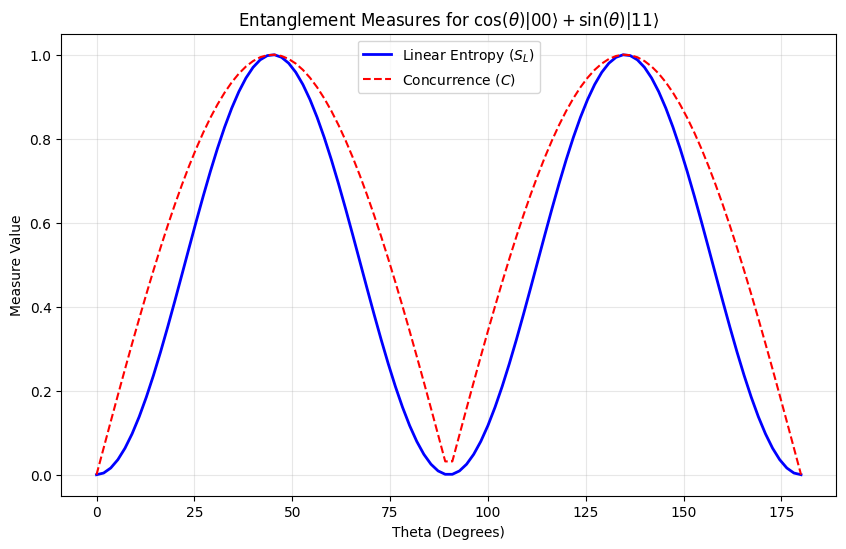

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, concurrence

def analyze_entanglement(theta_degrees):
    # Convert theta to radians
    theta = np.radians(theta_degrees)
    
    # 1. Construct the Statevector: cos(theta)|00> + sin(theta)|11>
    # Note: Qiskit uses |00> for |HH> and |11> for |VV>
    coeffs = [np.cos(theta), 0, 0, np.sin(theta)]
    phi = Statevector(coeffs)
    
    # 2. Construct the Global Density Matrix (rho)
    rho_global = DensityMatrix(phi)
    
    # 3. Check for Purity: Trace(rho^2) should be 1
    purity = np.real(np.trace(np.linalg.matrix_power(rho_global.data, 2)))
    
    # 4. Partial Trace to find reduced density matrix of qubit A (rho_a)
    rho_a = partial_trace(rho_global, [1]) # Trace out qubit 1
    
    # 5. Calculate Linear Entropy of subsystem A
    # Formula: 2 * (1 - Trace(rho_a^2)) for a qubit system
    rho_a_sq = np.linalg.matrix_power(rho_a.data, 2)
    linear_entropy = 2 * (1 - np.real(np.trace(rho_a_sq)))
    
    # 6. Calculate Concurrence
    # Directly from the state
    conf = concurrence(phi)
    
    return theta_degrees, purity, linear_entropy, conf

# --- Execution and Plotting ---

# User input for a specific theta
try:
    user_theta = float(input("Enter theta in degrees (e.g., 45 for maximally entangled): "))
    res = analyze_entanglement(user_theta)
    print(f"\nResults for theta = {user_theta}°:")
    print(f"  Purity: {res[1]:.4f}")
    print(f"  Linear Entropy (S_L): {res[2]:.4f}")
    print(f"  Concurrence (C): {res[3]:.4f}")
except ValueError:
    print("Please enter a valid number.")

# --- Generating the Graph ---
thetas = np.linspace(0, 180, 100)
entropy_vals = []
concurrence_vals = []

for t in thetas:
    _, _, s_l, c = analyze_entanglement(t)
    entropy_vals.append(s_l)
    concurrence_vals.append(c)

plt.figure(figsize=(10, 6))
plt.plot(thetas, entropy_vals, label='Linear Entropy ($S_L$)', color='blue', linewidth=2)
plt.plot(thetas, concurrence_vals, label='Concurrence ($C$)', color='red', linestyle='--')
plt.xlabel('Theta (Degrees)')
plt.ylabel('Measure Value')
plt.title(r'Entanglement Measures for $\cos(\theta)|00\rangle + \sin(\theta)|11\rangle$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()